# Blank Sample Anomaly Detection MVP

## 1. Project introduction

This notebook presents an MVP workflow for Blank sample anomaly detection using real QC data.

The workflow:

- identifies and cleans Blank QC records;
- checks whether explicit `< LOD` results are present;
- detects unusually high individual results;
- detects elevated rolling-baseline behaviour that may indicate collective drift;
- assesses instrument-specific behaviour where instrument data is available;
- applies robust statistical checks and Isolation Forest;
- produces candidate anomaly flags, tables and visualisations for analyst review.

Blank samples are used to identify possible contamination, background signal or analytical carryover. Blank data may be non-Gaussian, so the workflow uses median-based methods.

No explicit `< LOD` text values were found in the available export, so direct censored-value modelling could not be applied.

These are possible anomalies, not confirmed laboratory problems.


This notebook:

- cleans the available numeric Blank QC results;
- checks whether explicit `< LOD` results are present;
- detects unusually high individual results;
- detects elevated rolling-baseline behaviour that may indicate collective drift;
- identifies unusual behaviour within available instrument contexts;
- applies robust statistical methods and Isolation Forest;
- produces candidate anomaly flags, tables and visualisations for analyst review.

Blank anomalies may indicate contamination, background signal or analytical carryover. All findings are treated as candidate anomalies, not confirmed laboratory failures.

## Assumptions

- Blank records are identified using `ANALYTICAL_TYPE = Blank`.
- Blank results are expected to remain near zero or below the method detection limit, with low variation under normal conditions.
- The analysis uses the numeric concentration values available in the dataset.
- The dataset is checked for results reported explicitly as `< LOD`.
- No explicit `< LOD` text values were found, so direct censored-value modelling could not be applied.
- Point anomalies are represented by unusually high individual Blank results.
- Collective anomalies are represented by elevated rolling-baseline behaviour that may indicate drift.
- Contextual anomalies are assessed by instrument where instrument information is available.
- Shift-based contextual anomalies cannot be assessed because shift information is unavailable.
- Robust statistical methods are used because Blank data may be non-Gaussian.
- Isolation Forest supports the detection of unusual combinations of Blank features.
- All findings are candidate anomalies for analyst review because small deviations may be meaningful and false positives may cause unnecessary shutdowns or rework.

## User value

From a user perspective, this MVP answers a simple question:

**If real Blank QC data is uploaded, can the system return a useful Blank anomaly assessment?**

The notebook provides:

- extraction and cleaning of Blank records;
- checking for explicit `< LOD` results;
- detection of unusually high individual results;
- detection of elevated rolling-baseline behaviour that may indicate collective drift;
- assessment of instrument-specific anomalies where instrument information is available;
- robust statistical checks and Isolation Forest anomaly detection;
- candidate anomaly flags, explanations and visualisations for analyst review.

This demonstrates how Blank QC data can be analysed to identify unusual behaviour that may indicate contamination, background signal or analytical carryover.

## 2. Libraries and setup
This section imports the libraries required for Blank data cleaning, visualisation and anomaly detection.

In [353]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.ensemble import IsolationForest

RANDOM_STATE = 42

print("Blank anomaly-detection libraries loaded successfully.")

Blank anomaly-detection libraries loaded successfully.


## 3. Dataset validation

The notebook loads the real `QC_Sample_Data.csv` export and selects records where `ANALYTICAL_TYPE = Blank`.

The retained fields support:

- point anomalies using the reported Blank result;
- collective anomalies using results ordered by analysis date;
- contextual anomalies using instrument information where available;
- valid comparisons within the same scheme, analyte and unit.

The dataset is also checked for explicit `< LOD` reporting.

In [354]:
REQUIRED_COLUMNS = [
    "ANALYTICAL_TYPE",
    "SAMPLE_NAME_ANON",
    "JOB_NAME_ANON",
    "NUMERIC_FINAL_VALUE",
    "INTERNAL_TARGET_VALUE",
    "ANALYSED_DATE",
    "SCHEME_CODE",
    "ANALYTE_CODE",
    "UNIT_CODE",
    "INSTRUMENT_CODE",
]

# Search for the Blank QC dataset
candidate_paths = [
    Path("QC_Sample_Data.csv"),
    Path.cwd() / "QC_Sample_Data.csv",
    Path.cwd().parent / "QC_Sample_Data.csv",
]

SOURCE_PATH = next(
    (path for path in candidate_paths if path.is_file()),
    None
)

if SOURCE_PATH is None:
    raise FileNotFoundError(
        "QC_Sample_Data.csv was not found. "
        "Place it in the same folder as the notebook."
    )

raw = pd.read_csv(SOURCE_PATH, low_memory=False)

missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in raw.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

raw["ANALYSED_DATE"] = pd.to_datetime(
    raw["ANALYSED_DATE"],
    errors="coerce"
)

print("Blank source file:", SOURCE_PATH.resolve())
print("Total dataset rows:", len(raw))
print("Available columns:", raw.columns.tolist())

Blank source file: /Users/shivanshi/Desktop/datamine/QC_Sample_Data.csv
Total dataset rows: 1201152
Available columns: ['ANALYTICAL_TYPE', 'SAMPLE_NAME_ANON', 'JOB_NAME_ANON', 'NUMERIC_FINAL_VALUE', 'INTERNAL_TARGET_VALUE', 'ANALYSED_DATE', 'RECOVERY', 'SCHEME_CODE', 'SCHEME_VERSION', 'ANALYTE_CODE', 'RELATIVE_PERCENT_DIFFERENCE', 'STANDARD_STATUS', 'RECOVERY.1', 'PRECISION_STATUS', 'ANALYSED_BY_USER_ID', 'JOB_CLIENT_ID', 'UNIT_CODE', 'INSTRUMENT_CODE']


The relevant columns support the Blank analysis:

- `ANALYTICAL_TYPE` → identifies Blank records.
- `NUMERIC_FINAL_VALUE` → provides the reported Blank result for point-anomaly detection.
- `INTERNAL_TARGET_VALUE` → supports comparison with the expected Blank target or near-zero behaviour.
- `ANALYSED_DATE` → supports gradual baseline-drift detection.
- `INSTRUMENT_CODE` → supports contextual anomaly detection where instrument data is available.
- `SCHEME_CODE`, `ANALYTE_CODE`, `UNIT_CODE` → prevent incompatible Blank measurements from being compared.

## 4. Data loading and Blank extraction

The notebook loads `QC_Sample_Data.csv` and selects records where `ANALYTICAL_TYPE = Blank`.

The analysis retains:

- the reported result in `NUMERIC_FINAL_VALUE`;
- the expected Blank target;
- the analysis date;
- scheme, analyte and unit information;
- instrument information where available.

These fields support point-anomaly detection, gradual baseline-drift detection and instrument-specific contextual analysis.

The notebook also checks whether explicit `< LOD` values and instrument information are available.

In [355]:
REQUIRED_BLANK_COLUMNS = [
    "ANALYTICAL_TYPE",
    "NUMERIC_FINAL_VALUE",
    "INTERNAL_TARGET_VALUE",
    "ANALYSED_DATE",
    "SCHEME_CODE",
    "ANALYTE_CODE",
    "UNIT_CODE",
    "INSTRUMENT_CODE",
]

# Check that the required Blank columns exist
missing_columns = [
    column
    for column in REQUIRED_BLANK_COLUMNS
    if column not in raw.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required Blank columns: {missing_columns}"
    )

# Extract only Blank QC records
blank_df = raw[
    raw["ANALYTICAL_TYPE"]
    .astype(str)
    .str.strip()
    .str.casefold()
    .eq("blank")
].copy()

# Check whether results are explicitly reported as < LOD
lod_count = (
    blank_df["NUMERIC_FINAL_VALUE"]
    .astype(str)
    .str.contains(r"^\s*<", regex=True, na=False)
    .sum()
)

# Check information needed for Blank analysis
missing_target_count = blank_df["INTERNAL_TARGET_VALUE"].isna().sum()
missing_instrument_count = blank_df["INSTRUMENT_CODE"].isna().sum()

print("Blank rows extracted:", len(blank_df))
print("Rows reported as < LOD:", lod_count)
print("Rows with missing target values:", missing_target_count)
print("Rows with missing instrument codes:", missing_instrument_count)

display(
    blank_df[
        [
            "ANALYTICAL_TYPE",
            "NUMERIC_FINAL_VALUE",
            "INTERNAL_TARGET_VALUE",
            "ANALYSED_DATE",
            "SCHEME_CODE",
            "ANALYTE_CODE",
            "UNIT_CODE",
            "INSTRUMENT_CODE",
        ]
    ].head()
)

Blank rows extracted: 403601
Rows reported as < LOD: 0
Rows with missing target values: 1032
Rows with missing instrument codes: 192689


,ANALYTICAL_TYPE,NUMERIC_FINAL_VALUE,INTERNAL_TARGET_VALUE,ANALYSED_DATE,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,INSTRUMENT_CODE
2244,Blank,0,0,2019-02-05 11:36:07,AR10_MS,TE,PPM,NaN
2851,Blank,-0.0522951,0,2018-11-23 14:57:44,AR10_PATH,NI,PPM,NaN
2909,Blank,-0.0013632,0,2018-11-23 14:57:44,AR10_PATH,MO,PPM,NaN
2910,Blank,1.59979,0,2018-11-23 14:56:04,AR10_PATH,ZN,PPM,NaN
2912,Blank,-0.619004,0,2018-11-23 14:57:44,AR10_PATH,AU,PPB,NaN


The table shows the first five extracted Blank records.

Blank target values are 0.
Reported results can be zero, negative, or positive.
Missing INSTRUMENT_CODE values appear as NaN.
A non-zero value may be an anomaly candidate, but it must be compared with similar Blank results first.
The table confirms that the correct Blank fields were extracted.

## 5. Data cleaning and preparation

The Blank results are converted to numeric values and sorted by analysis date.

Rows missing the reported result, analysis date, scheme, analyte or unit are removed because they cannot support valid Blank anomaly analysis.

Missing instrument codes are retained because those rows can still be used for point-anomaly and baseline-drift analysis. Instrument-specific analysis will only use rows where an instrument code is available.

The dataset contains no explicit `< LOD` text values, so censored-value modelling is not applied.

In [356]:
# Convert Blank values to numeric
blank_df["NUMERIC_FINAL_VALUE"] = pd.to_numeric(
    blank_df["NUMERIC_FINAL_VALUE"],
    errors="coerce"
)

blank_df["INTERNAL_TARGET_VALUE"] = pd.to_numeric(
    blank_df["INTERNAL_TARGET_VALUE"],
    errors="coerce"
)

# Keep rows required for Blank anomaly analysis
analysis_df = blank_df.dropna(
    subset=[
        "NUMERIC_FINAL_VALUE",
        "ANALYSED_DATE",
        "SCHEME_CODE",
        "ANALYTE_CODE",
        "UNIT_CODE",
    ]
).copy()

# Sort chronologically for baseline-drift analysis
analysis_df = analysis_df.sort_values(
    "ANALYSED_DATE"
).reset_index(drop=True)

print("Blank rows before cleaning:", len(blank_df))
print("Blank rows available for analysis:", len(analysis_df))
print(
    "Rows available for instrument analysis:",
    analysis_df["INSTRUMENT_CODE"].notna().sum()
)

display(analysis_df.head())

Blank rows before cleaning: 403601
Blank rows available for analysis: 399864
Rows available for instrument analysis: 210906


,ANALYTICAL_TYPE,SAMPLE_NAME_ANON,JOB_NAME_ANON,NUMERIC_FINAL_VALUE,INTERNAL_TARGET_VALUE,ANALYSED_DATE,RECOVERY,SCHEME_CODE,SCHEME_VERSION,ANALYTE_CODE,RELATIVE_PERCENT_DIFFERENCE,STANDARD_STATUS,RECOVERY.1,PRECISION_STATUS,ANALYSED_BY_USER_ID,JOB_CLIENT_ID,UNIT_CODE,INSTRUMENT_CODE
0,Blank,SAMPLE_2FA929D49A80,JOB_31091FF1A222,0.00089,0,2018-11-16 08:30:09,0,AR10_PATH,2,TE,NaN,Pass,0,NaN,4C4036D145614BCD9031F842F5DFC51F,B9A96466322545D19E992CA223EA5DB1,PPM,NaN
1,Blank,SAMPLE_2FA929D49A80,JOB_31091FF1A222,0.00143,0,2018-11-16 08:30:09,0,AR10_PATH,2,W,NaN,Pass,0,NaN,4C4036D145614BCD9031F842F5DFC51F,B9A96466322545D19E992CA223EA5DB1,PPM,NaN
2,Blank,SAMPLE_2FA929D49A80,JOB_31091FF1A222,0.00083,0,2018-11-16 08:30:09,0,AR10_PATH,2,SB,NaN,Pass,0,NaN,4C4036D145614BCD9031F842F5DFC51F,B9A96466322545D19E992CA223EA5DB1,PPM,NaN
3,Blank,SAMPLE_2FA929D49A80,JOB_18A9B921A7A5,0.0002,0,2018-11-16 08:31:48,0,AR10_PATH,2,SB,NaN,Pass,0,NaN,4C4036D145614BCD9031F842F5DFC51F,B9A96466322545D19E992CA223EA5DB1,PPM,NaN
4,Blank,SAMPLE_2FA929D49A80,JOB_18A9B921A7A5,0.0012,0,2018-11-16 08:31:48,0,AR10_PATH,2,TE,NaN,Pass,0,NaN,4C4036D145614BCD9031F842F5DFC51F,B9A96466322545D19E992CA223EA5DB1,PPM,NaN


converts the Blank results to numeric values;
removes rows that cannot support valid analysis;
keeps missing instrument rows for point and drift analysis;
sorts by date for gradual baseline-drift detection;
counts rows available for instrument-specific analysis.

## 6. Exploratory analysis

This section checks whether the cleaned Blank results follow the expected behaviour described in the specification.

The analysis examines:

- whether results are generally near zero;
- whether the normal spread is low;
- how many results are zero, negative or positive;
- whether unusually large non-zero values are present;
- how many analytes and instruments are represented.

The dataset contains no explicit `< LOD` text values, so the analysis uses the numeric Blank results available in the export.

In [357]:
# Summarise the distribution of cleaned Blank results
blank_summary = analysis_df["NUMERIC_FINAL_VALUE"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

print("Blank result summary:")
display(blank_summary.to_frame(name="NUMERIC_FINAL_VALUE"))

# Count zero, negative and positive Blank results
zero_count = analysis_df["NUMERIC_FINAL_VALUE"].eq(0).sum()
negative_count = analysis_df["NUMERIC_FINAL_VALUE"].lt(0).sum()
positive_count = analysis_df["NUMERIC_FINAL_VALUE"].gt(0).sum()

print("Blank results equal to zero:", zero_count)
print("Negative Blank results:", negative_count)
print("Positive Blank results:", positive_count)

# Show the available analysis coverage
print("Unique analytes:", analysis_df["ANALYTE_CODE"].nunique())
print("Unique instruments available:", analysis_df["INSTRUMENT_CODE"].nunique())

Blank result summary:


,NUMERIC_FINAL_VALUE
count,"399,864"
mean,"4,230.23"
std,"43,216.4"
min,-300.445
1%,-1.524
5%,-0.0899867
25%,0
50%,9e-05
75%,0.00848
95%,1.6


Blank results equal to zero: 133882
Negative Blank results: 62514
Positive Blank results: 203468
Unique analytes: 77
Unique instruments available: 8


The cleaned Blank results are strongly right-skewed. Most results are close to zero, while a smaller number of large positive results increase the mean and standard deviation.

This supports the use of median-based methods rather than assuming a normal distribution. Positive values are not automatically anomalies because normal Blank behaviour differs between schemes, analytes and units.

<Figure size 1200x600 with 0 Axes>

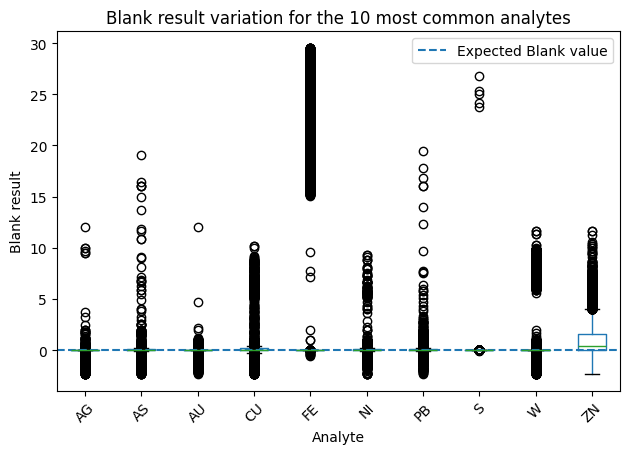

In [358]:
# Select the 10 analytes with the most Blank records
top_analytes = (
    analysis_df["ANALYTE_CODE"]
    .value_counts()
    .head(10)
    .index
)

plot_data = analysis_df[
    analysis_df["ANALYTE_CODE"].isin(top_analytes)
].copy()

# Limit extreme values so the main Blank behaviour remains visible
lower_limit = plot_data["NUMERIC_FINAL_VALUE"].quantile(0.01)
upper_limit = plot_data["NUMERIC_FINAL_VALUE"].quantile(0.99)

plot_data = plot_data[
    plot_data["NUMERIC_FINAL_VALUE"].between(
        lower_limit,
        upper_limit
    )
]

plt.figure(figsize=(12, 6))

plot_data.boxplot(
    column="NUMERIC_FINAL_VALUE",
    by="ANALYTE_CODE",
    grid=False
)

plt.axhline(
    0,
    linestyle="--",
    label="Expected Blank value"
)

plt.xlabel("Analyte")
plt.ylabel("Blank result")
plt.title("Blank result variation for the 10 most common analytes")
plt.suptitle("")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

The boxplot compares Blank result distributions across the ten most common analytes.

Most analytes are centred near the expected Blank value of zero. However, some analytes show wider variation and many unusually high results. These observations suggest possible point-anomaly candidates.

This graph is exploratory only. Results must still be assessed within the same scheme, analyte and unit before candidate anomalies are flagged.

This boxplot compares the Blank results for the 10 most common analytes. The dashed blue line at zero shows the expected Blank value. For each analyte, the box shows where most results fall, while the individual circles show values outside the main range. Most analytes have many results close to zero, which is expected for Blank samples. However, some analytes, especially Fe, Zn, As, Pb and W, show a wider spread and some much higher values. These may be possible anomaly candidates, but this graph alone does not confirm contamination because the results still need to be compared within the same scheme, unit and analytical context

## 7. Blank feature engineering

Blank results are compared within the same scheme, analyte and unit.

Robust median-based features are used because Blank data may be non-Gaussian. A rolling median is also calculated to identify elevated baseline behaviour that may indicate collective drift.

In [359]:
# Define comparable Blank groups
GROUP_COLUMNS = [
    "SCHEME_CODE",
    "ANALYTE_CODE",
    "UNIT_CODE",
]

# Difference from the expected Blank target
analysis_df["TARGET_DEVIATION"] = (
    analysis_df["NUMERIC_FINAL_VALUE"]
    - analysis_df["INTERNAL_TARGET_VALUE"]
)

# Typical result within each comparable group
analysis_df["GROUP_MEDIAN"] = (
    analysis_df.groupby(GROUP_COLUMNS)["NUMERIC_FINAL_VALUE"]
    .transform("median")
)

# Median absolute deviation for robust non-Gaussian analysis
analysis_df["ABS_MEDIAN_DEVIATION"] = (
    analysis_df["NUMERIC_FINAL_VALUE"]
    - analysis_df["GROUP_MEDIAN"]
).abs()

analysis_df["GROUP_MAD"] = (
    analysis_df.groupby(GROUP_COLUMNS)["ABS_MEDIAN_DEVIATION"]
    .transform("median")
)

# Robust score for sudden unusual results
analysis_df["ROBUST_Z_SCORE"] = np.where(
    analysis_df["GROUP_MAD"] > 0,
    0.6745
    * (analysis_df["NUMERIC_FINAL_VALUE"] - analysis_df["GROUP_MEDIAN"])
    / analysis_df["GROUP_MAD"],
    np.nan,
)

# Rolling median for gradual baseline drift
analysis_df["ROLLING_MEDIAN"] = (
    analysis_df.groupby(GROUP_COLUMNS)["NUMERIC_FINAL_VALUE"]
    .transform(
        lambda values: values.rolling(
            window=10,
            min_periods=3
        ).median()
    )
)

analysis_df["ROLLING_CHANGE"] = (
    analysis_df["ROLLING_MEDIAN"]
    - analysis_df["GROUP_MEDIAN"]
)

print("Blank feature engineering complete.")
display(analysis_df.head())

Blank feature engineering complete.


,ANALYTICAL_TYPE,SAMPLE_NAME_ANON,JOB_NAME_ANON,NUMERIC_FINAL_VALUE,INTERNAL_TARGET_VALUE,ANALYSED_DATE,RECOVERY,SCHEME_CODE,SCHEME_VERSION,ANALYTE_CODE,RELATIVE_PERCENT_DIFFERENCE,STANDARD_STATUS,RECOVERY.1,PRECISION_STATUS,ANALYSED_BY_USER_ID,JOB_CLIENT_ID,UNIT_CODE,INSTRUMENT_CODE,TARGET_DEVIATION,GROUP_MEDIAN,ABS_MEDIAN_DEVIATION,GROUP_MAD,ROBUST_Z_SCORE,ROLLING_MEDIAN,ROLLING_CHANGE
0,Blank,SAMPLE_2FA929D49A80,JOB_31091FF1A222,0.00089,0,2018-11-16 08:30:09,0,AR10_PATH,2,TE,NaN,Pass,0,NaN,4C4036D145614BCD9031F842F5DFC51F,B9A96466322545D19E992CA223EA5DB1,PPM,NaN,0.00089,-4e-05,0.00093,0.00095,0.6603,NaN,NaN
1,Blank,SAMPLE_2FA929D49A80,JOB_31091FF1A222,0.00143,0,2018-11-16 08:30:09,0,AR10_PATH,2,W,NaN,Pass,0,NaN,4C4036D145614BCD9031F842F5DFC51F,B9A96466322545D19E992CA223EA5DB1,PPM,NaN,0.00143,-0.0001,0.00153,0.00071,1.4535,NaN,NaN
2,Blank,SAMPLE_2FA929D49A80,JOB_31091FF1A222,0.00083,0,2018-11-16 08:30:09,0,AR10_PATH,2,SB,NaN,Pass,0,NaN,4C4036D145614BCD9031F842F5DFC51F,B9A96466322545D19E992CA223EA5DB1,PPM,NaN,0.00083,0.00017,0.00066,0.00061,0.729787,NaN,NaN
3,Blank,SAMPLE_2FA929D49A80,JOB_18A9B921A7A5,0.0002,0,2018-11-16 08:31:48,0,AR10_PATH,2,SB,NaN,Pass,0,NaN,4C4036D145614BCD9031F842F5DFC51F,B9A96466322545D19E992CA223EA5DB1,PPM,NaN,0.0002,0.00017,3e-05,0.00061,0.0331721,NaN,NaN
4,Blank,SAMPLE_2FA929D49A80,JOB_18A9B921A7A5,0.0012,0,2018-11-16 08:31:48,0,AR10_PATH,2,TE,NaN,Pass,0,NaN,4C4036D145614BCD9031F842F5DFC51F,B9A96466322545D19E992CA223EA5DB1,PPM,NaN,0.0012,-4e-05,0.00124,0.00095,0.8804,NaN,NaN


The engineered features compare Blank results within the same scheme, analyte and unit.

The robust Z-score identifies individual results that are unusually high compared with normal group behaviour. The rolling median tracks the local Blank baseline over time and supports the identification of elevated collective behaviour.

Missing rolling values at the beginning of some groups are expected because at least three results are required. These features identify candidate unusual behaviour and do not confirm contamination.

## 8. Blank anomaly flags

This section creates candidate flags for the three anomaly patterns in the Blank specification:

- **Point anomalies:** sudden unusually high non-zero results.
- **Collective anomalies:** gradual upward movement in the Blank baseline.
- **Contextual anomalies:** unusual behaviour associated with particular instruments.

The flags are candidate indicators only and do not confirm contamination, background signal or analytical carryover.

In [360]:
# Point anomaly:
# flag results that are unusually high within the same scheme, analyte and unit.
analysis_df["POINT_ANOMALY"] = (
    analysis_df["ROBUST_Z_SCORE"] > 3
)

# Collective anomaly:
# flag rolling Blank baselines that are unusually above normal group behaviour.
analysis_df["DRIFT_ANOMALY"] = (
    (analysis_df["GROUP_MAD"] > 0)
    & (
        analysis_df["ROLLING_MEDIAN"]
        > analysis_df["GROUP_MEDIAN"]
        + 3 * analysis_df["GROUP_MAD"]
    )
)

# Contextual anomaly:
# compare each instrument's typical result with the overall comparable group.
INSTRUMENT_GROUP_COLUMNS = GROUP_COLUMNS + ["INSTRUMENT_CODE"]

analysis_df["INSTRUMENT_MEDIAN"] = (
    analysis_df
    .groupby(
        INSTRUMENT_GROUP_COLUMNS,
        dropna=False
    )["NUMERIC_FINAL_VALUE"]
    .transform("median")
)

analysis_df["INSTRUMENT_CONTEXT_SCORE"] = np.where(
    analysis_df["GROUP_MAD"] > 0,
    (
        analysis_df["INSTRUMENT_MEDIAN"]
        - analysis_df["GROUP_MEDIAN"]
    )
    / analysis_df["GROUP_MAD"],
    np.nan,
)

analysis_df["CONTEXTUAL_ANOMALY"] = (
    analysis_df["INSTRUMENT_CODE"].notna()
    & (analysis_df["INSTRUMENT_CONTEXT_SCORE"] > 3)
)

print(
    "Point-anomaly candidates:",
    analysis_df["POINT_ANOMALY"].sum()
)

print(
    "Baseline-drift candidates:",
    analysis_df["DRIFT_ANOMALY"].sum()
)

print(
    "Instrument-context candidates:",
    analysis_df["CONTEXTUAL_ANOMALY"].sum()
)

Point-anomaly candidates: 12708
Baseline-drift candidates: 6268
Instrument-context candidates: 425


The Blank checks found:

- **12,708 point-anomaly candidates** — individual Blank results that were much higher than the normal result for the same scheme, analyte and unit.
- **6,268 baseline-drift candidates** — groups where the rolling Blank baseline had moved unusually far above its normal level.
- **425 instrument-context candidates** — instruments whose typical Blank result was unusually high compared with similar results from the same scheme, analyte and unit.

These results do not prove contamination. They only identify unusual Blank behaviour that should be reviewed by an analyst.

## 9. Rule-based Blank assessment

Before applying machine learning, the notebook combines the Blank-specific point, rolling-baseline and contextual checks into one explainable baseline.

The rule-based baseline follows the Blank anomaly patterns in the project specification:

- sudden unusually high results are treated as point-anomaly candidates;
- unusually elevated rolling-baseline behaviour is treated as a collective-anomaly candidate that may indicate drift;
- unusually high behaviour linked to a particular instrument is treated as a contextual-anomaly candidate.

This baseline is later compared with Isolation Forest. All flags are candidate anomalies only and do not confirm contamination.

In [361]:
# Combine the three Blank-specific rule checks
analysis_df["RULE_BASED_ANOMALY"] = (
    analysis_df[
        [
            "POINT_ANOMALY",
            "DRIFT_ANOMALY",
            "CONTEXTUAL_ANOMALY",
        ]
    ].any(axis=1)
)

# Summarise each rule-based Blank flag
rule_summary = pd.DataFrame(
    {
        "Rule": [
            "Point anomaly",
            "Baseline drift",
            "Instrument context",
            "Any rule-based anomaly",
        ],
        "Count": [
            int(analysis_df["POINT_ANOMALY"].sum()),
            int(analysis_df["DRIFT_ANOMALY"].sum()),
            int(analysis_df["CONTEXTUAL_ANOMALY"].sum()),
            int(analysis_df["RULE_BASED_ANOMALY"].sum()),
        ],
    }
)

display(rule_summary)

,Rule,Count
0,Point anomaly,12708
1,Baseline drift,6268
2,Instrument context,425
3,Any rule-based anomaly,16118


The rule-based baseline identified 16,118 unique Blank records as candidate anomalies.

This total is lower than the sum of the individual rule counts because some records were flagged by more than one rule. For example, a result may be both a sudden point anomaly and part of an elevated baseline drift.

These results provide the explainable baseline that will be compared with the Isolation Forest model.

## 10. Machine learning anomaly detection

Isolation Forest is used as the machine-learning anomaly-detection method.

It is an unsupervised model, so confirmed anomaly labels are not required. This is appropriate because the dataset does not identify which Blank results are confirmed contamination events.

The model uses three Blank-specific features:

- unusually high individual results;
- unusually high rolling baseline movement;
- unusually high instrument-specific behaviour.

The features are scaled using each scheme, analyte and unit group's median absolute deviation. This prevents measurements with different normal ranges or units from being compared directly.

A conservative anomaly proportion of 1% is used because the Blank specification states that false positives can cause unnecessary shutdowns or rework. Model outputs are candidate anomalies only.

In [362]:
# Convert the Blank-specific measures into positive anomaly scores.
# Negative deviations are set to zero because the Blank specification
# focuses on unusually high results and upward baseline movement.

analysis_df["POSITIVE_POINT_SCORE"] = (
    analysis_df["ROBUST_Z_SCORE"].clip(lower=0)
)

analysis_df["DRIFT_SCORE"] = np.where(
    analysis_df["GROUP_MAD"] > 0,
    analysis_df["ROLLING_CHANGE"] / analysis_df["GROUP_MAD"],
    np.nan,
)

analysis_df["POSITIVE_DRIFT_SCORE"] = (
    analysis_df["DRIFT_SCORE"].clip(lower=0)
)

analysis_df["POSITIVE_CONTEXT_SCORE"] = (
    analysis_df["INSTRUMENT_CONTEXT_SCORE"].clip(lower=0)
)

MODEL_FEATURES = [
    "POSITIVE_POINT_SCORE",
    "POSITIVE_DRIFT_SCORE",
    "POSITIVE_CONTEXT_SCORE",
]

model_data = (
    analysis_df[MODEL_FEATURES]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

isolation_forest = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

analysis_df["ISOLATION_FOREST_ANOMALY"] = (
    isolation_forest.fit_predict(model_data) == -1
)

analysis_df["ISOLATION_FOREST_SCORE"] = (
    -isolation_forest.score_samples(model_data)
)

print("Isolation Forest anomaly counts:")
print(
    analysis_df["ISOLATION_FOREST_ANOMALY"]
    .value_counts()
)

print(
    "\nIsolation Forest candidate percentage:",
    round(
        analysis_df["ISOLATION_FOREST_ANOMALY"].mean() * 100,
        2
    ),
    "%"
)

Isolation Forest anomaly counts:
ISOLATION_FOREST_ANOMALY
False    395873
True       3991
Name: count, dtype: int64

Isolation Forest candidate percentage: 1.0 %


Isolation Forest identified 3,991 Blank records as machine-learning anomaly candidates, representing 1% of the cleaned Blank dataset.

The 1% candidate rate was set as a conservative modelling choice because false Blank alarms may lead to unnecessary investigation, shutdowns or rework.

The model identifies unusual combinations of point, baseline-drift and instrument-context behaviour. These records are candidate anomalies only and do not confirm contamination.

In [363]:
# Show the Isolation Forest candidate rate for each analyte
anomalies_by_analyte = (
    analysis_df
    .groupby("ANALYTE_CODE")["ISOLATION_FOREST_ANOMALY"]
    .mean()
    .mul(100)
    .round(2)
    .rename("AnomalyRatePct")
    .reset_index()
    .sort_values("AnomalyRatePct", ascending=False)
    .head(10)
)

display(anomalies_by_analyte)

,ANALYTE_CODE,AnomalyRatePct
10,BE,13.07
28,HF,7.55
9,BAO,7.14
19,CS,6.51
8,BA,5.8
67,TM,5.64
66,TL,5.56
15,CE,3.27
14,CD,2.48
3,AS,1.97


The highest Isolation Forest candidate rate was found for **BE (13.07%)**, followed by **HF (7.55%)**, **BAO (7.14%)**, **CS (6.51%)** and **BA (5.80%)**.

These percentages show which analytes contain the largest proportion of machine-learning anomaly candidates. However, a high percentage does not automatically mean contamination because some analytes may have only a small number of Blank records.

The results are exploratory and must still be reviewed within the same scheme and unit.

## 11. Rule-based and Isolation Forest comparison

This section compares the explainable Blank rules with the Isolation Forest model.

The comparison shows:

- records flagged by both approaches;
- records flagged only by the rule-based baseline;
- records flagged only by Isolation Forest;
- records flagged by neither approach.

Agreement between both approaches provides stronger evidence of unusual Blank behaviour. However, all results remain candidate anomalies and require analyst review.

In [364]:
# Compare the rule-based baseline with Isolation Forest
analysis_df["COMPARISON_GROUP"] = np.select(
    [
        analysis_df["RULE_BASED_ANOMALY"]
        & analysis_df["ISOLATION_FOREST_ANOMALY"],

        analysis_df["RULE_BASED_ANOMALY"]
        & ~analysis_df["ISOLATION_FOREST_ANOMALY"],

        ~analysis_df["RULE_BASED_ANOMALY"]
        & analysis_df["ISOLATION_FOREST_ANOMALY"],
    ],
    [
        "Both",
        "Rule only",
        "Isolation Forest only",
    ],
    default="Neither",
)

comparison_summary = (
    analysis_df["COMPARISON_GROUP"]
    .value_counts()
    .reindex(
        [
            "Both",
            "Rule only",
            "Isolation Forest only",
            "Neither",
        ],
        fill_value=0,
    )
    .rename_axis("Comparison")
    .reset_index(name="Count")
)

comparison_summary["Percent"] = (
    comparison_summary["Count"]
    / len(analysis_df)
    * 100
).round(2)

display(comparison_summary)

,Comparison,Count,Percent
0,Both,3409,0.85
1,Rule only,12709,3.18
2,Isolation Forest only,582,0.15
3,Neither,383164,95.82


Isolation Forest provides a smaller, prioritised set of unusual records and captures some additional multivariate patterns, while the rule-based system provides broader and more explainable coverage of the Blank specification.

## 12. Final Blank candidate results

Blank records identified by both the rule-based baseline and Isolation Forest are prioritised for review.

Agreement between both methods provides stronger evidence of unusual behaviour, but it does not confirm contamination, background signal or analytical carryover.

In [365]:
analysis_df["REVIEW_PRIORITY"] = np.select(
    [
        analysis_df["RULE_BASED_ANOMALY"]
        & analysis_df["ISOLATION_FOREST_ANOMALY"],

        analysis_df["RULE_BASED_ANOMALY"]
        | analysis_df["ISOLATION_FOREST_ANOMALY"],
    ],
    [
        "High priority",
        "Review",
    ],
    default="Not flagged",
)

priority_summary = (
    analysis_df["REVIEW_PRIORITY"]
    .value_counts()
    .rename_axis("ReviewPriority")
    .reset_index(name="Count")
)

display(priority_summary)

,ReviewPriority,Count
0,Not flagged,383164
1,Review,13291
2,High priority,3409


In [366]:
candidate_results = analysis_df[
    analysis_df["REVIEW_PRIORITY"] != "Not flagged"
].copy()

candidate_results = candidate_results.sort_values(
    [
        "REVIEW_PRIORITY",
        "ISOLATION_FOREST_SCORE",
    ],
    ascending=[True, False],
)

display(
    candidate_results[
        [
            "ANALYSED_DATE",
            "SCHEME_CODE",
            "ANALYTE_CODE",
            "UNIT_CODE",
            "INSTRUMENT_CODE",
            "NUMERIC_FINAL_VALUE",
            "POINT_ANOMALY",
            "DRIFT_ANOMALY",
            "CONTEXTUAL_ANOMALY",
            "ISOLATION_FOREST_ANOMALY",
            "REVIEW_PRIORITY",
        ]
    ].head(20)
)

,ANALYSED_DATE,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,INSTRUMENT_CODE,NUMERIC_FINAL_VALUE,POINT_ANOMALY,DRIFT_ANOMALY,CONTEXTUAL_ANOMALY,ISOLATION_FOREST_ANOMALY,REVIEW_PRIORITY
202664,2020-12-10 10:17:15,AR25_MS,CD,PPM,NaN,0.008,True,True,False,True,High priority
388589,2021-12-24 12:23:08,AR25_MS,AS,PPM,NaN,0.48,True,True,False,True,High priority
202469,2020-12-10 08:55:14,AR25_MS,CD,PPM,NaN,0.0072,True,True,False,True,High priority
371642,2021-11-09 20:14:10,AR25_MS,AS,PPM,NaN,0.4,True,True,False,True,High priority
373568,2021-11-12 20:07:57,AR25_MS,AS,PPM,NaN,0.4,True,True,False,True,High priority
376487,2021-11-19 17:19:58,AR25_MS,AS,PPM,NaN,0.4,True,True,False,True,High priority
377458,2021-11-23 13:45:48,AR25_MS,AS,PPM,NaN,0.4,True,True,False,True,High priority
377495,2021-11-23 14:46:37,AR25_MS,AS,PPM,NaN,0.4,True,True,False,True,High priority
377513,2021-11-23 15:06:41,AR25_MS,AS,PPM,NaN,0.4,True,True,False,True,High priority
378514,2021-11-25 09:52:16,AR25_MS,AS,PPM,NaN,0.4,True,True,False,True,High priority


What it shows:

High priority means both the Blank rules and Isolation Forest flagged the record.
POINT_ANOMALY = True means the individual result was unusually high.
DRIFT_ANOMALY = True means it also occurred during an elevated rolling baseline.
CONTEXTUAL_ANOMALY = False here because the instrument code is missing, so instrument context could not be assessed.
Repeated AS values of 0.4 PPM across several dates suggest a sustained elevated pattern, not just one isolated spike.